# Conformal envelopes (generated data)

We simulate two labels, A and B, and four predictors for each candidate label:

Scores lie between 0 and 1; higher means stronger evidence for that candidate (simulated scores, not fitted or calibrated probabilities). A and B each have their own score columns, supplied through `label_to_columns`. 

Training and test data are independent draws from the same generator. Test labels are used only for evaluation.

In [1]:
import sys
from pathlib import Path
from time import perf_counter
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


LIBRARY_PARENT = None
if LIBRARY_PARENT is not None:
    sys.path.insert(0, str(Path(LIBRARY_PARENT).resolve()))
else:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / "conformal_envelopes" / "__init__.py").is_file():
            sys.path.insert(0, str(parent))
            break

from conformal_envelopes import ConformalSetModel, evaluate_prediction_sets
import conformal_envelopes
print("Library:", conformal_envelopes.__file__)

Library: /home/siddiqun/Bureau/Internship/Conformal Library/conformal_envelopes/__init__.py


## Settings

In [2]:
SEED = 21
ALPHA = 0.10              # target miscoverage level
N_TRAIN = 1500            # number of training points
N_TEST = 500              # number of test points
MISSING_RATE = 0.15       # probability of hiding each score
CORRELATION = 0.90        # correlation between the good and correlated 
GOOD_SIGNAL = 1.8         # strength of the label dependent shift for the strong predictors
WEAK_SIGNAL = 0.35        # smaller label-dependent shift for the weak predicto

In [3]:
CLASSES = ["A", "B"]

## - good: strong evidence about whether the candidate label is correct or not 
## - correlated: strong evidence, very similar to good
## - weak: a little useful evidence
## - noise: no useful evidence
PREDICTORS = ["good", "correlated", "weak", "noise"] 

# tells the library which columns to use while asessing each candidate
label_to_columns = {label: [f"{label}_{name}" for name in PREDICTORS] for label in CLASSES}
score_cols = [c for label in CLASSES for c in label_to_columns[label]]
METHOD_PARAMS = {"collapsed": {},
                 "radial": {"n_directions": 100, "smoothing": 4.0, 
                            "angle_deg": 30.0, "neighbor_fraction": 0.2},
                 "strip": {"n_bins": 8, "min_samples": 3},}

## Generating the data
Using the simulated label to create the joint distribution of labels and scores. 

In [4]:
def generate_data(n, rng, prefix):
    #checking invalid parameters
    if not 0 <= MISSING_RATE < 1:
        raise ValueError("MISSING_RATE must be in [0, 1).")
    if not -1 <= CORRELATION <= 1:
        raise ValueError("CORRELATION must be in [-1, 1].")

    # generating true labels and IDs
    labels = rng.choice(CLASSES, size=n)
    # creating IDs
    clean = pd.DataFrame({"ID": [f"{prefix}_{i:05d}" for i in range(n)]})

    # loop runs once for each candidate
    for label, columns in label_to_columns.items():
        # assigns whether the candidate matches the true label or not
        sign = np.where(labels == label, 1.0, -1.0)
        # creating noise
        z = rng.normal(size=n)
        z_correlated = (CORRELATION * z + np.sqrt(1 - CORRELATION**2) * rng.normal(size=n))
        latent = np.column_stack([GOOD_SIGNAL * sign + z, GOOD_SIGNAL * sign + z_correlated, 
                                  WEAK_SIGNAL * sign + rng.normal(0, 1.5, size=n),])
        # converting scores to [0,1] and generting a 4th predictor which is just noise
        values = np.column_stack([1 / (1 + np.exp(-latent)),  rng.uniform(0, 1, size=n),])
        clean[columns] = values

    # keeping the labels and creatign missing data
    clean["label"] = labels
    observed = clean.copy()
    for columns in label_to_columns.values():
        mask = rng.random((n, len(columns))) < MISSING_RATE
        empty = mask.all(axis=1)
        while empty.any():
            mask[empty] = rng.random((int(empty.sum()), len(columns))) < MISSING_RATE
            empty = mask.all(axis=1)
        observed[columns] = observed[columns].mask(mask)
    return observed, clean

In [5]:
train_seed, test_seed = np.random.SeedSequence(SEED).spawn(2)
train, train_complete = generate_data(N_TRAIN, np.random.default_rng(train_seed), "train")
test, test_complete = generate_data(N_TEST, np.random.default_rng(test_seed), "test")

assert set(train.ID).isdisjoint(test.ID)
for columns in label_to_columns.values():
    # check that IDs do not overlap
    assert train[columns].notna().any(axis=1).all()
    assert test[columns].notna().any(axis=1).all()

print("Training rows:", len(train), "| Test rows:", len(test))
display(train.head())
display(pd.DataFrame({"train": train.label.value_counts(),
                      "test": test.label.value_counts()}))
display(train[score_cols].isna().mean().rename("missing_fraction").to_frame())

Training rows: 1500 | Test rows: 500


,ID,A_good,A_correlated,A_weak,A_noise,B_good,B_correlated,B_weak,B_noise,label
0,train_00000,0.038034,0.047347,0.209763,0.105064,0.948477,NaN,0.543925,NaN,B
1,train_00001,0.781596,0.751752,0.836537,0.210397,NaN,0.227077,0.526796,0.749087,A
2,train_00002,0.978690,0.972557,0.857263,0.686121,0.159451,0.151823,0.684528,0.421560,A
3,train_00003,0.767047,0.852949,NaN,0.542982,0.082622,0.099537,0.210167,0.321702,A
4,train_00004,0.395874,0.324960,0.274637,0.860710,0.668439,0.736342,0.822849,0.857412,B


,train,test
label,,
A,754,247
B,746,253


,missing_fraction
A_good,0.124000
A_correlated,0.155333
A_weak,0.144667
A_noise,0.154000
B_good,0.151333
B_correlated,0.151333
B_weak,0.151333
B_noise,0.142667


## Checking if the predictors behave as intended
Using training data only. Within-class correlations distinguish shared predictor noise from correlation caused simply by separating A and B.

,A_good,A_correlated,A_weak,A_noise
label,,,,
A,0.812,0.814,0.558,0.502
B,0.171,0.176,0.441,0.491


Candidate A scores, true class A: correlations


,A_good,A_correlated,A_weak,A_noise
A_good,1.00,0.88,-0.05,0.04
A_correlated,0.88,1.00,-0.03,0.03
A_weak,-0.05,-0.03,1.00,-0.03
A_noise,0.04,0.03,-0.03,1.00


Candidate A scores, true class B: correlations


,A_good,A_correlated,A_weak,A_noise
A_good,1.00,0.88,-0.04,0.02
A_correlated,0.88,1.00,-0.02,0.01
A_weak,-0.04,-0.02,1.00,-0.01
A_noise,0.02,0.01,-0.01,1.00


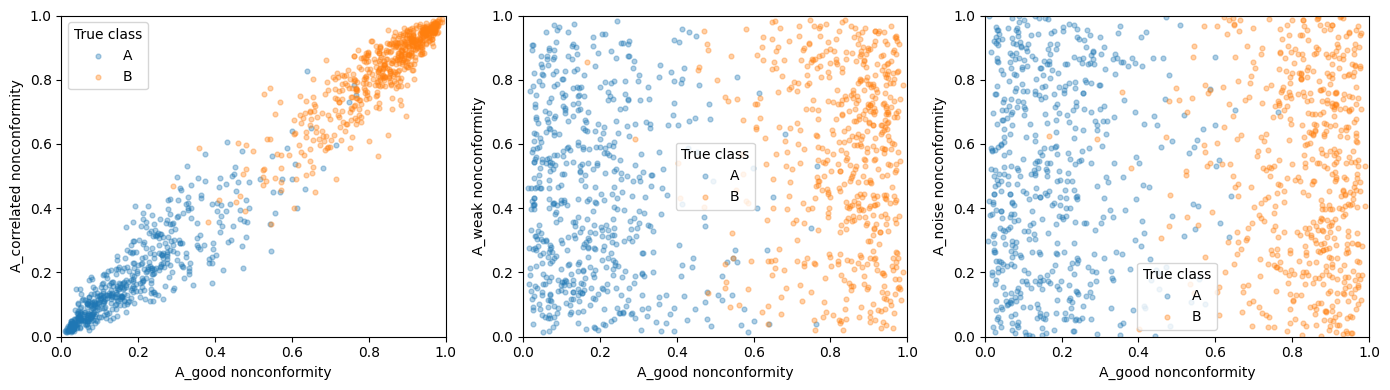

In [6]:
candidate = "A"
columns = label_to_columns[candidate]
# computes mean A scores separately for true-A and true-B observations.
display(train_complete.groupby("label")[columns].mean().round(3))
for true_label in CLASSES:
    print(f"Candidate A scores, true class {true_label}: correlations")
    display(train_complete.loc[train_complete.label.eq(true_label), columns].corr().round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = {"A": "tab:blue", "B": "tab:orange"}
for ax, second in zip(axes, ["correlated", "weak", "noise"]):
    for label in CLASSES:
        rows = train.loc[train.label.eq(label)]
        ax.scatter(1-rows.A_good, 1-rows[f"A_{second}"], s=12, alpha=0.35, color=colors[label], label=label)
    ax.set(xlabel="A_good nonconformity", ylabel=f"A_{second} nonconformity", xlim=(0, 1), ylim=(0, 1))
    ax.legend(title="True class")
plt.tight_layout()
plt.show()

## Fitting and evaluating all three methods
Each method fits one envelope per label. 
- The library splits training rows into shape discovery S1 and calibration S2. 
- NaNs remain NaNs: we do not fill them with zeros. 
- Forced predictions are disabled so empty sets remain visible.

- Coverage is the fraction of test prediction sets containing the true label. 
- Set size measures ambiguity.

In [7]:
models = {}
predictions = {}
summary = []

# runs teh same procedure for all the methods
for method, parameters in METHOD_PARAMS.items():
    model = ConformalSetModel(method=method, alpha=ALPHA, random_state=SEED,
                              score_direction="higher_is_better", shape_fraction=0.5,
                              force_nonempty=False, **parameters,)
    start = perf_counter()

    # recieves the training labels and candidate specific score mappings - one envelope per label
    model.fit(train, id_col="ID", label_col="label", score_cols=score_cols,
              label_to_columns=label_to_columns)
    fit_seconds = perf_counter() - start
    start = perf_counter()

    # predicting (without teh test labels)
    result = model.predict(test.drop(columns="label"))
    predict_seconds = perf_counter() - start
    truth = test.set_index("ID").loc[result["ID"], "label"].tolist()

    # calculating the metrics
    metrics = evaluate_prediction_sets(result["prediction_set"], truth)
    summary.append({"method": method, **metrics, "fit_seconds": fit_seconds, 
                    "predict_seconds": predict_seconds, "forced": int(result["forced"].sum())})
    models[method] = model
    predictions[method] = result

summary = pd.DataFrame(summary).set_index("method")
display(summary.round(4))
print("Nominal target:", 1-ALPHA)

,coverage,average_set_size,singleton_rate,singleton_accuracy,empty_rate,per_class_coverage,fit_seconds,predict_seconds,forced
method,,,,,,,,,
collapsed,0.890,1.010,0.794,0.9849,0.098,"{'A': 0.8704453441295547, 'B': 0.9090909090909...",0.0072,0.0362,0
radial,0.914,1.096,0.760,0.9816,0.072,"{'A': 0.8825910931174089, 'B': 0.9446640316205...",0.0547,0.0693,0
strip,0.910,0.970,0.854,0.9977,0.088,"{'A': 0.902834008097166, 'B': 0.9169960474308301}",0.0341,0.0373,0


Nominal target: 0.9


In [8]:
class_rows = []
for method, result in predictions.items():
    truth = test.set_index("ID").loc[result.ID, "label"].to_numpy()
    covered = np.array([y in labels for y, labels in zip(truth, result.prediction_set)])
    for label in CLASSES:
        selected = truth == label
        class_rows.append({"method": method, "label": label, "n_test": int(selected.sum()),
                           "coverage": covered[selected].mean(),
                           "mean_set_size": result.loc[selected, "set_size"].mean()})
display(pd.DataFrame(class_rows).round(4))

,method,label,n_test,coverage,mean_set_size
0,collapsed,A,247,0.8704,0.9798
1,collapsed,B,253,0.9091,1.0395
2,radial,A,247,0.8826,1.0526
3,radial,B,253,0.9447,1.1383
4,strip,A,247,0.9028,0.9636
5,strip,B,253,0.9170,0.9763


## Inspecting envelopes and prediction sets
The dictionary below gives one conformal set per test ID.

In [9]:
envelope_rows = []
for method, model in models.items():
    for label, info in model.get_envelopes().items():
        envelope_rows.append({"method": method, "label": label, "shape_n": info["shape_size"],
                              "calibration_n": info["calibration_size"],
                              "t_hat": info["envelope"]["t_hat"]})
display(pd.DataFrame(envelope_rows))

,method,label,shape_n,calibration_n,t_hat
0,collapsed,A,377,377,1.001939
1,collapsed,B,373,373,0.985766
2,radial,A,377,377,1.005441
3,radial,B,373,373,1.032962
4,strip,A,377,377,1.017538
5,strip,B,373,373,0.984175


In [10]:
result = predictions["strip"]
display(result[["ID", "prediction_set", "set_size", "forced"]].head(10))

,ID,prediction_set,set_size,forced
0,test_00000,[A],1,False
1,test_00001,[A],1,False
2,test_00002,[B],1,False
3,test_00003,"[A, B]",2,False
4,test_00004,[A],1,False
5,test_00005,[A],1,False
6,test_00006,[B],1,False
7,test_00007,[B],1,False
8,test_00008,[B],1,False
9,test_00009,[B],1,False


In [11]:
prediction_sets_by_id = dict(zip(result.ID, result.prediction_set))
print(dict(list(prediction_sets_by_id.items())[:5]))

{'test_00000': ['A'], 'test_00001': ['A'], 'test_00002': ['B'], 'test_00003': ['A', 'B'], 'test_00004': ['A']}


## Plotting envelopes in nonconformity space
The library stores only each class's assigned columns. Therefore, to show other classes under candidate-specific mappings, we overlay their observed points from the full training frame here; we do not ask the library for columns it did not store. All points use the selected candidate's score columns.

In [12]:
PLOT_LABEL = "B"       # "A" or "B"
x = f"{PLOT_LABEL}_good"   # "good", "correlated", "weak", or "noise"
y = f"{PLOT_LABEL}_weak"

#### Slice of the full envelope; other coordinates fixed at training medians. Point categories use full-model decisions

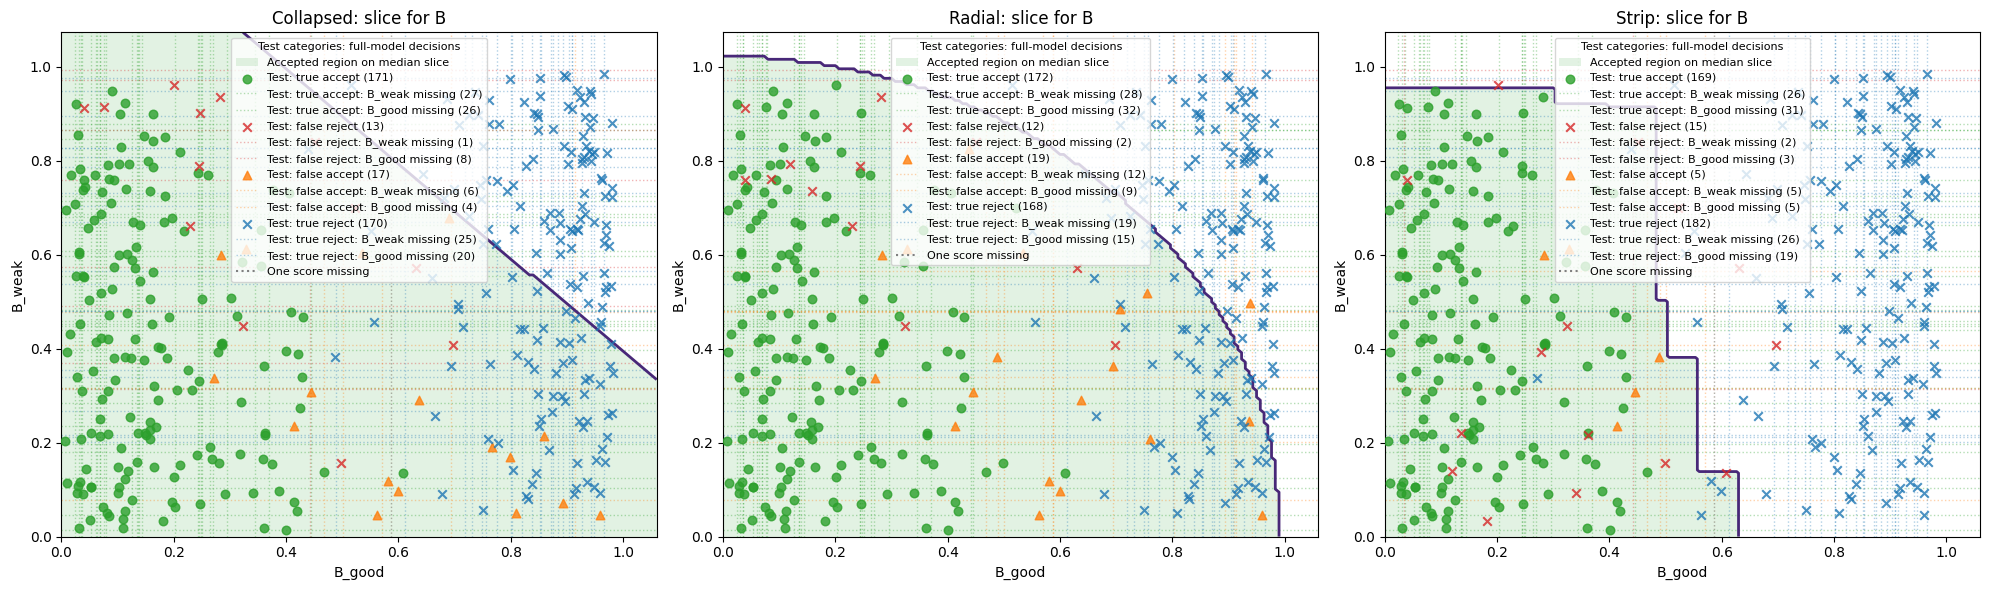

In [13]:
plot_test = test.copy()

fig, axes = plt.subplots(1, len(models), figsize=(20, 6), squeeze=False,)

for ax, model in zip(axes.ravel(), models.values()):
    model.plot_slice(x=x, y=y, label=PLOT_LABEL, test_data=plot_test, show_training=False,
                     show_missing=True, ax=ax,)

plt.tight_layout()
plt.show()

#### Separate 2D fit; point categories use the 2D envelope

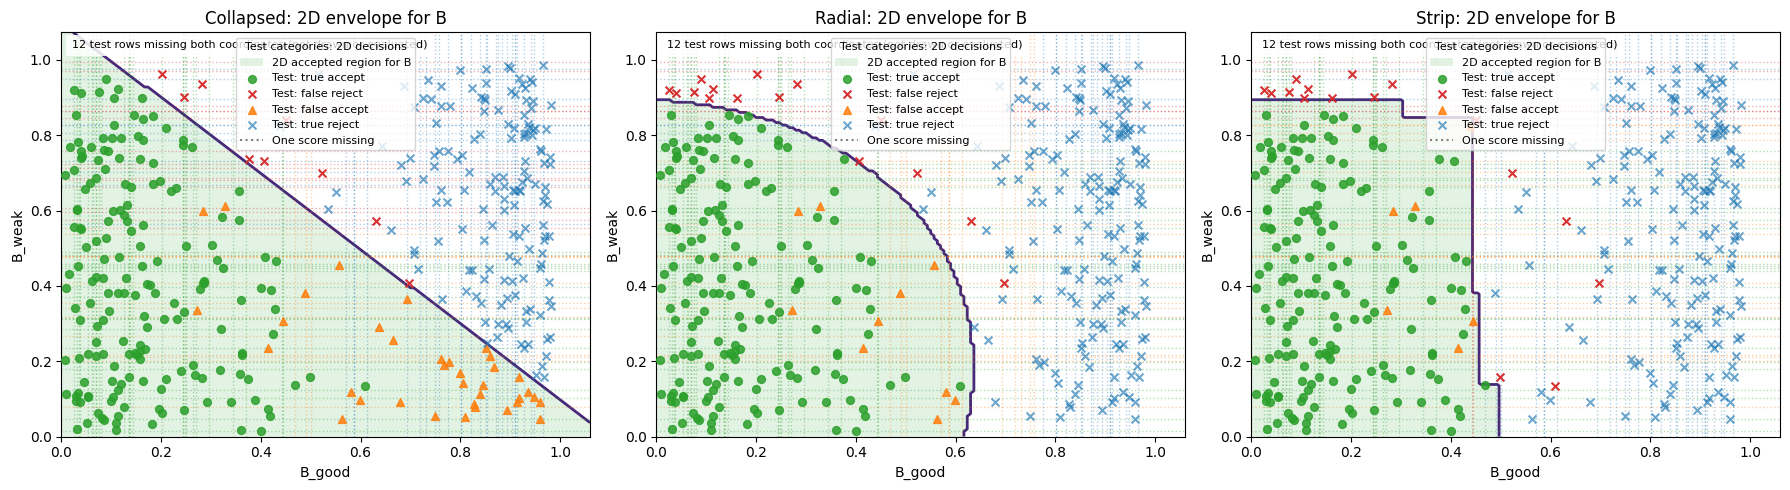

In [14]:
plot_test = test.copy()

fig, axes = plt.subplots(1, len(models), figsize=(18, 5), squeeze=False)

for ax, model in zip(axes.ravel(), models.values()):
    model.plot(x=x, y=y, label=PLOT_LABEL, test_data=plot_test, show_training=False, 
               show_other_classes=False, show_missing=True, ax=ax,)

plt.tight_layout()
plt.show()